# Module 3: Remote Sensing with Deep Learning (EuroSAT)

We move beyond "shallow" machine learning to **Convolutional Neural Networks (CNNs)**.

### Spatial Hierarchies in CNNs
CNNs are powerful because they learn hierarchical features:
1. **Bottom Layers**: Detect simple edges and textures.
2. **Middle Layers**: Combine edges into shapes.
3. **Top Layers**: Recognize complex objects (e.g., a "building" or a "river").

### Loss Functions: Cross-Entropy
Since this is a multi-class categorization task, we use **Cross-Entropy Loss**, which measures the performance of a classification model whose output is a probability value between 0 and 1.

## Task:
Classify satellite imagery patches into land use categories.

## 1. Environment Setup & Data Loading
We will use **PyTorch** and **Torchvision** to download and prepare the EuroSAT dataset. EuroSAT consists of Sentinel-2 satellite images covering 10 land cover classes.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Subset

# Define transformations: Convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

# Download and load the EuroSAT dataset
try:
    dataset = torchvision.datasets.EuroSAT(root='./data', download=True, transform=transform)
except Exception as e:
    print(f"Could not automatically download EuroSAT: {e}")
    print("You may need to download it manually or use the HuggingFace datasets library.")
    # Fallback to a small dummy dataset for illustration if download fails completely
    dataset = torch.utils.data.TensorDataset(torch.randn(100, 3, 64, 64), torch.randint(0, 10, (100,)))


dataset = Subset(dataset, range(20000))

# Split into training and validation sets (75/25)
train_size = int(0.75 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Training samples: 15000, Validation samples: 5000


## 2. Convolutional Neural Network (CNN) Architecture

We will define a simple CNN with 3 convolutional blocks followed by fully connected (linear) layers.

**Architecture:**
```mermaid
graph TD
    Input[Input Image 64x64x3] --> Conv1[Conv2d + ReLU + MaxPool]
    Conv1 --> Conv2[Conv2d + ReLU + MaxPool]
    Conv2 --> Conv3[Conv2d + ReLU + MaxPool]
    Conv3 --> Flatten[Flatten Layer]
    Flatten --> FC1[Linear (Fully Connected) + ReLU]
    FC1 --> Output[Linear (10 classes)]
```

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # Block 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 3
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully Connected Layers
        # Image size after 3 max pools of size 2 is 64 / (2*2*2) = 8
        self.fc1 = nn.Linear(in_features=64 * 8 * 8, out_features=128)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)
        
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        
        x = x.view(x.size(0), -1) # Flatten
        
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate model
model = SimpleCNN(num_classes=10)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (relu4): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 3. Training Loop
We use **CrossEntropyLoss** for multi-class classification and the **Adam** optimizer to update the network weights based on the computed gradients.

Training on cpu...
Epoch 1/5 - Loss: 0.9358
Epoch 2/5 - Loss: 0.5746
Epoch 3/5 - Loss: 0.4638
Epoch 4/5 - Loss: 0.3970
Epoch 5/5 - Loss: 0.3443


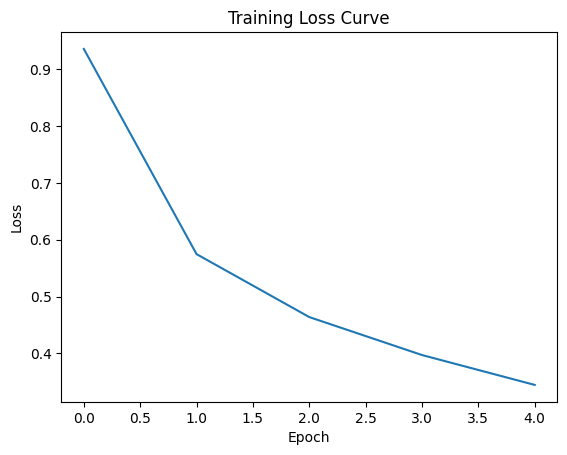

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5 # Set low for demonstration purposes
train_losses = []

print(f"Training on {device}...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")

plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 4. Model Evaluation

After training, we evaluate the model's accuracy on the unseen validation set.

In [12]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 86.32%


## 5. Core Deep Learning Concepts

### Perceptrons & Multi-Layer Perceptrons (MLP)
A **Perceptron** is the simplest artificial neuron. It takes inputs, multiplies them by weights, adds a bias, and passes the sum through an activation function. When we stack many perceptrons in hidden layers, we create a **Multi-Layer Perceptron (MLP)**.

### Activation Functions
Activation functions introduce non-linearity, allowing the network to learn complex patterns.
- **ReLU (Rectified Linear Unit)**: $f(x) = \max(0, x)$. Most common in hidden layers; helps mitigate the vanishing gradient problem.
- **Sigmoid**: Squashes values between 0 and 1. Used in binary classification.
- **Tanh**: Squashes values between -1 and 1.

### Optimizers
Optimizers decide how to update the network weights based on the calculated gradients.
- **SGD (Stochastic Gradient Descent)**: Updates weights taking small steps down the gradient slope.
- **Adam (Adaptive Moment Estimation)**: Adapts the learning rate for each parameter individually and retains momentum from previous updates. Generally converges faster than standard SGD.